In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from PIL import Image

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Knee Osteoporosis Dataset multiclasses

## 1. Introdução ao território.

O Dataset traz imagens de raio-x dos ossos na região do joelho, distribuidos em 3 classes: _**Normal**_, _**Osteopenia**_ e _**Osteoporose**_. O diagnóstico de Osteoporose trata-se de uma condição de baixa densidade óssea, enquanto Osteopenia é um estado inicial de perda de densidade óssea, que pode evoluir para uma Osteoporose se não houver cuidado.

## 2. Carregamento dos dados.

Estrutura do Dataset:
```Bash
Osteoporosis Knee X-ray/
├── normal/ (36 arquivos .JPEG .jpg)
├── osteopenia/ (154 arquivos .JPEG .jpg)
├── osteoporosis/ (49 arquivos .JPEG .jpg)
└── patient details.xlsx
```

In [2]:
# CARREGANDO METADADOS

excel_path = r"D:\study\DATASETS\Knee Osteoporosis Dataset multiclasses\Osteoporosis Knee X-ray\patient details.xlsx"
images_path = r"D:\study\DATASETS\Knee Osteoporosis Dataset multiclasses\Osteoporosis Knee X-ray"

try:
    df = pd.read_excel(excel_path)
    print(f"Arquivo Excel carregado com sucesso ✓")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print(f"Arquivo não encontrado em {excel_path} ✗")
    df = None

Arquivo Excel carregado com sucesso ✓
Shape: (243, 28)


## 3. Visão geral do terreno.

O dataset reune apenas 239 imagens, o que é considerado pouco para aplicar CNN. Além disso, as classes possuem **distribuição desbalanceada**.

As últimas linhas da planilha reunem estatíticas quanto as colunas `"Age"`, `"height  (meter)"` e `"Weight (KG) "` e não devem fazer parte dos metadados.

In [3]:
statistics = df.loc[
    df["Patient Id"].isna(), # rows
    ["Menopause Age", "Age", "height  (meter)", "Weight (KG) "] # cols
]
statistics.columns = ["statistic", "age", "height (m)", "weight (kg)"]

df = df[~df["Patient Id"].isna()]

statistics

,statistic,age,height (m),weight (kg)
240,max,107.000000,1.828800,98.000000
241,min,17.000000,1.371600,39.000000
242,avg,51.045833,1.585659,69.058333


In [4]:
df.describe()

,S.No,Age,height (meter),Weight (KG),Number of Pregnancies,Maximum Walking distance (km),T-score Value,Z-Score Value,BMI:
count,240.00000,240.000000,240.000000,240.000000,124.000000,239.000000,240.000000,240.000000,240.000000
mean,120.50000,51.045833,1.585659,69.058333,3.443548,1.940167,-1.833625,-1.327292,27.590448
std,69.42622,12.622040,0.095789,9.574457,1.466717,1.991257,0.687243,0.675927,4.043308
min,1.00000,17.000000,1.371600,39.000000,1.000000,0.100000,-2.990000,-2.990000,16.139658
25%,60.75000,44.750000,1.520000,63.000000,2.000000,0.500000,-2.322500,-1.820000,24.956260
50%,120.50000,50.000000,1.570000,69.000000,3.000000,1.000000,-2.010000,-1.190000,27.285722
75%,180.25000,60.000000,1.652500,74.250000,4.000000,3.000000,-1.287500,-0.852500,30.210129
max,240.00000,107.000000,1.828800,98.000000,7.000000,10.000000,-0.160000,0.730000,42.754389


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   S.No                            240 non-null    float64
 1   Patient Id                      240 non-null    object 
 2   Joint Pain:                     240 non-null    object 
 3   Gender                          240 non-null    object 
 4   Age                             240 non-null    float64
 5   Menopause Age                   83 non-null     object 
 6   height  (meter)                 240 non-null    float64
 7   Weight (KG)                     240 non-null    float64
 8   Smoker                          240 non-null    object 
 9   Alcoholic                       240 non-null    object 
 10  Diabetic                        240 non-null    object 
 11  Hypothyroidism                  240 non-null    object 
 12  Number of Pregnancies           124 non-n

## 4. Análise exploratória e mapas visuais.

**DISTRIBUIÇÃO**

Dataset desbalanceado!

<Axes: ylabel='count'>

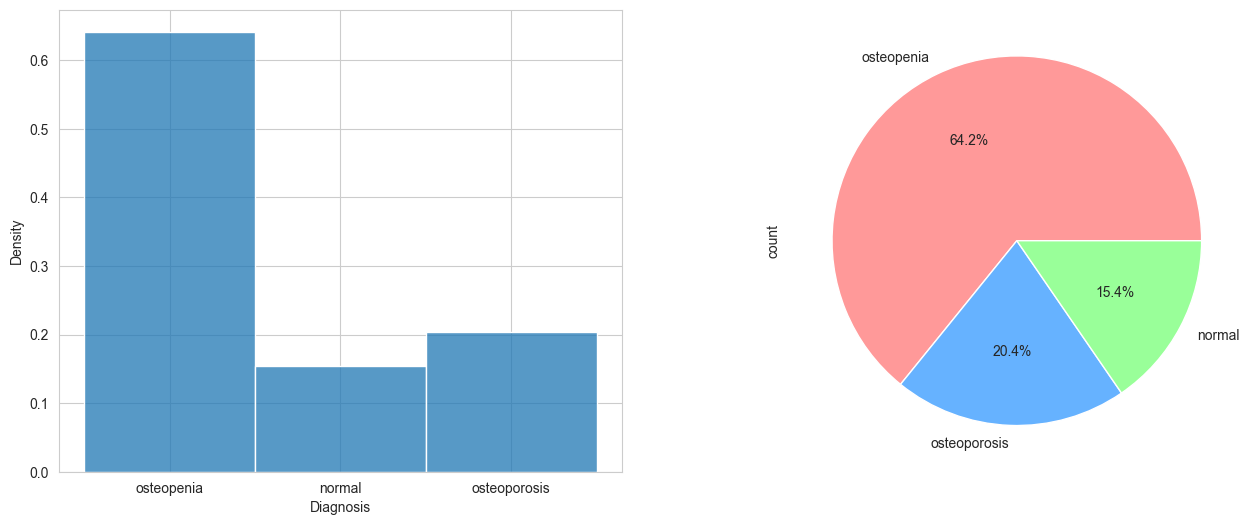

In [6]:
param = "Diagnosis"

fig, ax = plt.subplots(1, 2, figsize=(16,6))

sns.histplot(df[param], stat="density", ax=ax[0])

counts = df[param].value_counts()
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#FF9999', '#66B2FF', '#99FF99'])

<Axes: xlabel='Age', ylabel='Density'>

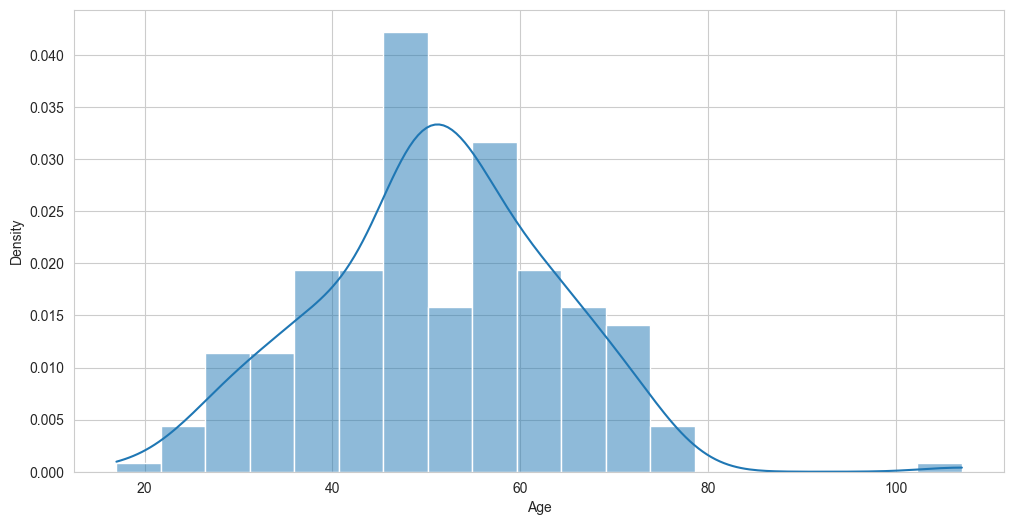

In [7]:
param = "Age"
# param = "T-score Value"
# param = "height  (meter)"
# param = "Weight (KG) "
# param = "Maximum Walking distance (km)"


sns.histplot(df[param], kde=True, stat="density") # Kernel Density Estimation

In [8]:
pd.crosstab(df["Gender"], df["Diagnosis"], normalize="index")

Diagnosis,normal,osteopenia,osteoporosis
Gender,,,
female,0.143939,0.719697,0.136364
male,0.166667,0.546296,0.287037


<Axes: xlabel='Age', ylabel='T-score Value'>

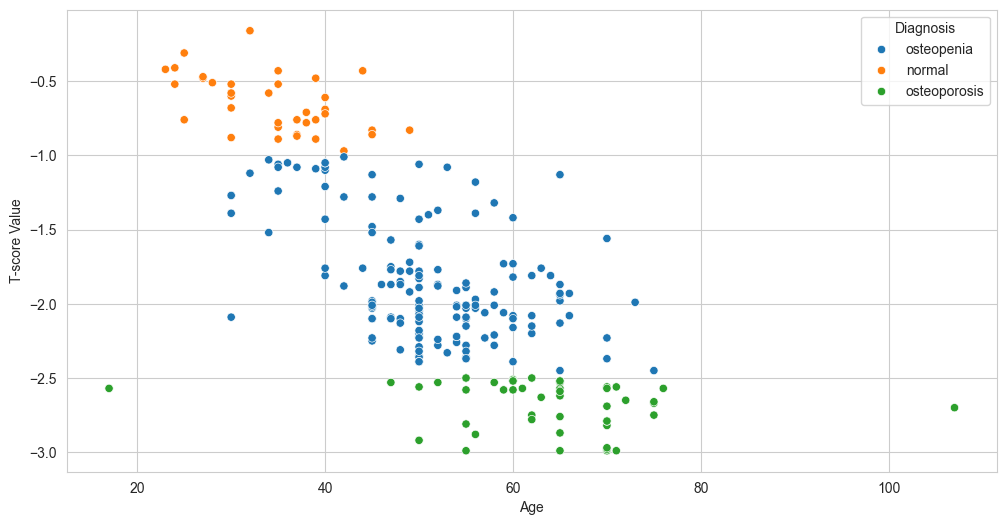

In [9]:
sns.scatterplot(x="Age", y="T-score Value", hue="Diagnosis", data=df)
# sns.scatterplot(x="Age", y="Z-Score Value", hue="Diagnosis", data=df)

O T-score compara o paciente com um adulto jovem saudável (pico de massa óssea). <br> Em termos simples: _**“Quão distante o paciente está do ideal?”**_

- ≥ -1 → normal
- entre -1 e -2.5 → osteopenia
- ≤ -2.5 → osteoporose

Já o Z-score compara o paciente com pessoas semelhantes (mesma idade, sexo). <br> Em termos simples: _**“Quão diferente ele está de pessoas como ele?”**_

- próximo de 0 → dentro do esperado
- muito negativo → abaixo do esperado para a idade

## 5. Perigos e limitações.

**VALORES NULOS**

<Axes: >

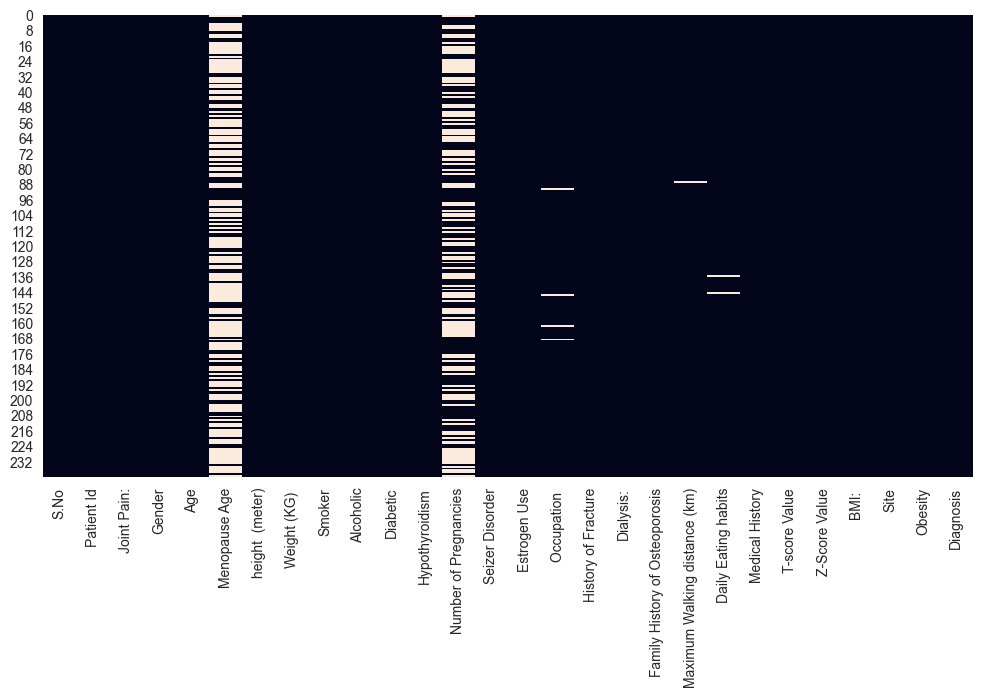

In [10]:
sns.heatmap(df.isna(), cbar=False)

In [11]:
df[df["Menopause Age"].isna()]
# df[df["Number of Pregnancies"].isna()]
# df[df["Occupation "].isna()]
# df[df["Maximum Walking distance (km)"].isna()]
# df[df["Daily Eating habits"].isna()]

,S.No,Patient Id,Joint Pain:,Gender,Age,Menopause Age,height (meter),Weight (KG),Smoker,Alcoholic,...,Family History of Osteoporosis,Maximum Walking distance (km),Daily Eating habits,Medical History,T-score Value,Z-Score Value,BMI:,Site,Obesity,Diagnosis
0,1.0,OP1,yes,male,65.0,NaN,1.64592,65.0,yes,no,...,no,0.2,normal,normal,-1.98,0.73,23.993627,knee,normal weight,osteopenia
4,5.0,OP5,yes,female,40.0,NaN,1.49352,54.0,no,no,...,no,2.0,normal,depression,-1.81,-1.05,24.208711,knee,normal weight,osteopenia
5,6.0,OP6,yes,male,53.0,NaN,1.61544,64.0,no,no,...,no,5.0,low protiens,"R.arthritis, appendix",-1.08,-0.46,24.524395,knee,normal weight,osteopenia
6,7.0,OP7,yes,male,60.0,NaN,1.52400,64.0,yes,no,...,no,1.0,normal,no,-1.73,-0.92,27.555611,knee,over weight,osteopenia
7,8.0,OP8,yes,female,46.0,NaN,1.43256,63.0,no,no,...,no,2.0,normal,no,-1.87,-1.59,30.698341,knee,obesity,osteopenia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,235.0,OP151,yes,male,54.0,NaN,1.69000,68.0,no,no,...,yes,6.0,normal,no,-2.02,-2.45,23.808690,knee,normal weight,osteopenia
235,236.0,OP152,yes,female,56.0,NaN,1.54000,80.0,no,no,...,yes,0.2,normal,"scizerian, b.p",-1.97,-1.34,33.732501,knee,obesity,osteopenia
236,237.0,OS49,yes,male,55.0,NaN,1.53000,63.0,no,no,...,no,6.0,normal,heart,-2.99,-2.42,26.912726,knee,over weight,osteoporosis
237,238.0,OP153,yes,male,49.0,NaN,1.67000,88.0,no,no,...,yes,0.5,normal,"G.B rem, fatty liver",-1.72,-1.21,31.553659,knee,obesity,osteopenia


In [12]:
df["Menopause Age"].isna().mean()

np.float64(0.6541666666666667)

**TRATAMENTO DE DADOS**

In [13]:
df = df.drop(columns=["Menopause Age"]) # muitos valores nulos

df["Number of Pregnancies"] = df["Number of Pregnancies"].fillna(0) # contextualmente faz sentido

df["Maximum Walking distance (km)"] = df["Maximum Walking distance (km)"].fillna(
    df["Maximum Walking distance (km)"].median()
)

df["Occupation "] = df["Occupation "].fillna("Unknown")
df["Daily Eating habits"] = df["Daily Eating habits"].fillna("Unknown")

unique_columns = df.columns[df.nunique() <= 1]
df = df.drop(columns=unique_columns)

Foi observado que não tem imagem no Dataset para o registro N37

In [14]:
df[df["Patient Id"] == "N37"]

,S.No,Patient Id,Joint Pain:,Gender,Age,height (meter),Weight (KG),Smoker,Diabetic,Hypothyroidism,...,Dialysis:,Family History of Osteoporosis,Maximum Walking distance (km),Daily Eating habits,Medical History,T-score Value,Z-Score Value,BMI:,Obesity,Diagnosis
239,240.0,N37,yes,male,39.0,1.63,70.0,no,no,no,...,no,no,5.0,low salt,no,-0.76,-0.59,26.346494,over weight,normal


In [15]:
df = df[df["Patient Id"] != "N37"]

Sem valores nulos, agora é possível análisar agrupamento de classes no t-SNE.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

Text(0.5, 1.0, 't-SNE Visualization')

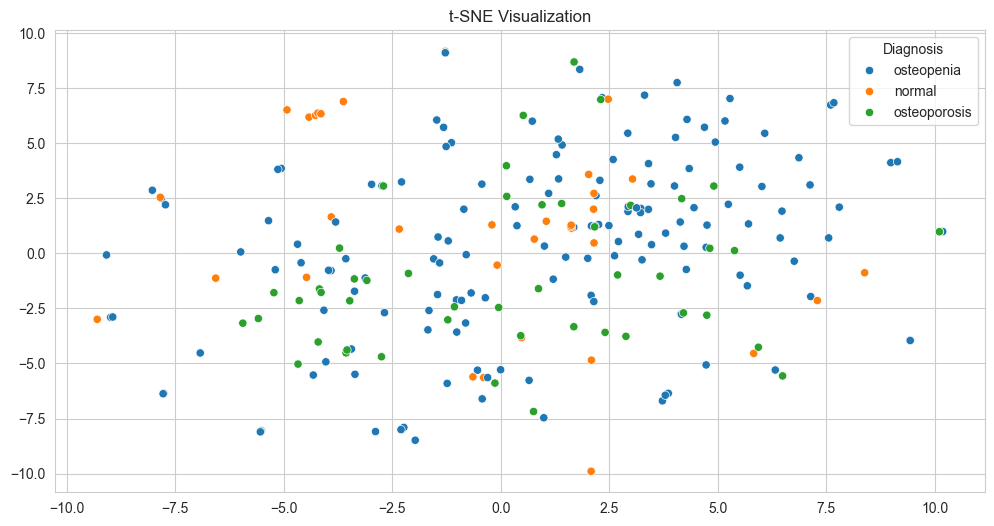

In [17]:
# t-SNE

X = df.drop(columns=["Diagnosis"])
X = pd.get_dummies(X)

X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df["Diagnosis"])
plt.title("t-SNE Visualization")

## 6. Conclusão e recomendação.

Uma vez que o diagnóstico é baseado justamente no T-score, considerar esse parâmetro entrega a resposta ao modelo.

Dessa forma, se o objetivo for predição de alta qualidade clínica, as imagens podem nem mesmo ser necessárias, visto que o diagnóstico está fortemente relacionado ao T-score.

Se o foco for aprendizado real é recomendável eliminar T-score, e também Z-score para manter apenas os parâmetros clinicos. 

**PREDIÇÃO BÁSICA**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
df = df.drop(columns=['S.No'])
df.columns

Index(['Patient Id', 'Joint Pain:', 'Gender', 'Age', 'height  (meter)',
       'Weight (KG) ', 'Smoker', 'Diabetic', 'Hypothyroidism',
       'Number of Pregnancies', 'Seizer Disorder', 'Estrogen Use',
       'Occupation ', 'History of Fracture', 'Dialysis:',
       'Family History of Osteoporosis', 'Maximum Walking distance (km)',
       'Daily Eating habits', 'Medical History', 'T-score Value',
       'Z-Score Value', 'BMI: ', 'Obesity', 'Diagnosis'],
      dtype='object')

In [20]:
# RANDOM FOREST CLASSIFIER

x = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9583333333333334

Classification Report:
               precision    recall  f1-score   support

      normal       1.00      0.71      0.83         7
  osteopenia       0.94      1.00      0.97        31
osteoporosis       1.00      1.00      1.00        10

    accuracy                           0.96        48
   macro avg       0.98      0.90      0.93        48
weighted avg       0.96      0.96      0.96        48



Text(0.5, 1.0, 'Confusion Matrix')

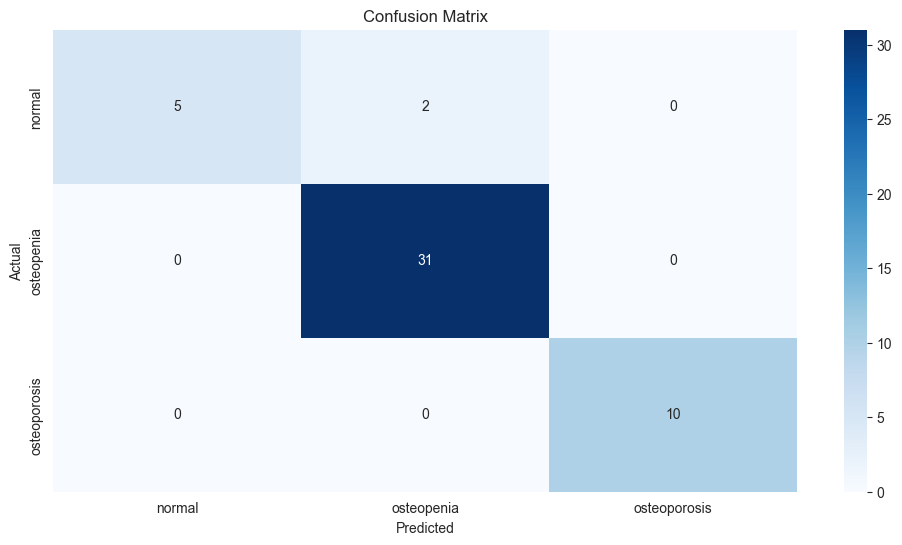

In [21]:
# MATRIZ DE CONFUSÃO
cmatrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(
    cmatrix, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [22]:
# FEATURES
importances = pd.Series(model.feature_importances_, index=x.columns)
print(importances.sort_values(ascending=False))

T-score Value                     0.288722
Age                               0.099833
Z-Score Value                     0.087582
BMI:                              0.036444
Weight (KG)                       0.034396
                                    ...   
Medical History_fatty liver       0.000000
Patient Id_N29                    0.000000
Medical History_scizerian, b.p    0.000000
Medical History_seizer, B.P       0.000000
Obesity_under weight              0.000000
Length: 441, dtype: float64


**APRENDIZADO REAL**

In [23]:
df = df.drop(columns=["T-score Value", "Z-Score Value"])
# df = df.drop(columns=['T-score Value', 'Z-Score Value', 'S.No', 'Seizer Disorder', 'Occupation ', 'Dialysis:', 'Daily Eating habits', 'Medical History'])
df.columns

Index(['Patient Id', 'Joint Pain:', 'Gender', 'Age', 'height  (meter)',
       'Weight (KG) ', 'Smoker', 'Diabetic', 'Hypothyroidism',
       'Number of Pregnancies', 'Seizer Disorder', 'Estrogen Use',
       'Occupation ', 'History of Fracture', 'Dialysis:',
       'Family History of Osteoporosis', 'Maximum Walking distance (km)',
       'Daily Eating habits', 'Medical History', 'BMI: ', 'Obesity',
       'Diagnosis'],
      dtype='object')

In [24]:
import os
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import models, transforms
from collections import Counter

In [25]:
# CNN

"""
CNN Simples para Classificação de Raio-X de Joelho
===================================================
3 classes: normal | osteopenia | osteoporose

Estrutura do dataset:
    Osteoporosis Knee X-ray/
    ├── normal/        (36 imagens)
    ├── osteopenia/    (154 imagens)
    └── osteoporosis/  (49 imagens)
"""


DATASET_ROOT = "D:\study\DATASETS\Knee Osteoporosis Dataset multiclasses\Osteoporosis Knee X-ray"
CLASSES      = ["normal", "osteopenia", "osteoporosis"]
BATCH_SIZE   = 16
NUM_EPOCHS   = 5
LR           = 1e-4
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[OK] Device: {DEVICE}")


# DATASET
# Cada imagem recebe um label de acordo com a pasta:
#   normal/       → 0
#   osteopenia/   → 1
#   osteoporosis/ → 2

class RaioXDataset(Dataset):

    def __init__(self, root, classes, transform=None):
        self.transform    = transform
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples      = []                      # lista de (caminho, label)

        for classe in classes:
            pasta = os.path.join(root, classe)
            for arquivo in sorted(os.listdir(pasta)):
                if arquivo.lower().endswith((".jpg", ".jpeg")):
                    caminho = os.path.join(pasta, arquivo)
                    label   = self.class_to_idx[classe]
                    self.samples.append((caminho, label))

        # contagem = Counter(lbl for _, lbl in self.samples)
        # print(f"[DATASET] {len(self.samples)} imagens encontradas:")
        # for classe, idx in self.class_to_idx.items():
        #     print(f"   {classe}: {contagem[idx]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        caminho, label = self.samples[idx]
        img = Image.open(caminho).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def __str__(self):
        contagem = Counter(lbl for _, lbl in self.samples)
        string = f"[DATASET] {len(self.samples)} imagens encontradas:"
        for classe, idx in self.class_to_idx.items():
            string = string + f"\n   {classe}: {contagem[idx]}"
        return string


# TRANSFORMS
# Treino: pequenas augmentações para o modelo generalizar
# Val:    só redimensiona e normaliza (sem augmentação)

transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# DIVISÃO TREINO / VALIDAÇÃO
# Dividimos manualmente para garantir que cada classe fique proporcional nos dois conjuntos (stratify)

dataset_base = RaioXDataset(DATASET_ROOT, CLASSES, transform=None)
print(dataset_base)

# Separa os índices por classe
indices_por_classe = {i: [] for i in range(len(CLASSES))}
for idx, (_, label) in enumerate(dataset_base.samples):
    indices_por_classe[label].append(idx)

# 80% treino / 20% val por classe
indices_treino, indices_val = [], []
for label, indices in indices_por_classe.items():
    corte = int(len(indices) * 0.8)
    indices_treino.extend(indices[:corte])
    indices_val.extend(indices[corte:])

print(f"\n[SPLIT] Treino: {len(indices_treino)} | Val: {len(indices_val)}")

# Subsets com transforms diferentes
ds_treino_base = RaioXDataset(DATASET_ROOT, CLASSES, transform=transform_treino)
ds_val_base    = RaioXDataset(DATASET_ROOT, CLASSES, transform=transform_val)

ds_treino = Subset(ds_treino_base, indices_treino)
ds_val    = Subset(ds_val_base,    indices_val)


# BALANCEAMENTO
# mais peso às classes menores no treino

labels_treino = [ds_treino_base.samples[i][1] for i in indices_treino]
contagem      = Counter(labels_treino)
pesos         = [1.0 / contagem[lbl] for lbl in labels_treino]

sampler = WeightedRandomSampler(
    weights=torch.tensor(pesos),
    num_samples=len(pesos),
    replacement=True
)

loader_treino = DataLoader(ds_treino, batch_size=BATCH_SIZE, sampler=sampler)
loader_val    = DataLoader(ds_val,    batch_size=BATCH_SIZE, shuffle=False)


# MODELO ResNet18
# trocamos a última camada (fc) para 3 classes

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model    = model.to(DEVICE)

print(f"\n[MODELO] ResNet18 carregada. Saída: {len(CLASSES)} classes.")


# TREINO

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()


def rodar_epoca(model, loader, optimizer, criterion, treino: bool):
    """Roda uma época completa de treino OU validação."""
    model.train() if treino else model.eval()

    loss_total, acertos, total = 0.0, 0, 0

    # torch.set_grad_enabled liga/desliga backprop automaticamente
    with torch.set_grad_enabled(treino):
        for imagens, labels in loader:
            imagens = imagens.to(DEVICE)
            labels  = labels.to(DEVICE)

            if treino:
                optimizer.zero_grad()         # 1. zera gradientes acumulados

            saida = model(imagens)            # 2. forward pass
            loss  = criterion(saida, labels)  # 3. calcula loss

            if treino:
                loss.backward()               # 4. calcula gradientes
                optimizer.step()             # 5. atualiza pesos

            preds = saida.argmax(dim=1)
            acertos    += (preds == labels).sum().item()
            total      += labels.size(0)
            loss_total += loss.item() * labels.size(0)

    return loss_total / total, acertos / total


# LOOP PRINCIPAL

print("[INÍCIO DO TREINO]")

for epoca in range(1, NUM_EPOCHS + 1):
    loss_t, acc_t = rodar_epoca(model, loader_treino, optimizer, criterion, treino=True)
    loss_v, acc_v = rodar_epoca(model, loader_val,    optimizer, criterion, treino=False)

    print(f"[{epoca:2d}/{NUM_EPOCHS:2d}]  "
          f"treino  loss={loss_t:.4f}  acc={acc_t:.3f}  |  "
          f"val  loss={loss_v:.4f}  acc={acc_v:.3f}")

[OK] Device: cuda
[DATASET] 239 imagens encontradas:
   normal: 36
   osteopenia: 154
   osteoporosis: 49

[SPLIT] Treino: 190 | Val: 49

[MODELO] ResNet18 carregada. Saída: 3 classes.
[INÍCIO DO TREINO]
[ 1/ 5]  treino  loss=0.9535  acc=0.542  |  val  loss=0.9952  acc=0.592
[ 2/ 5]  treino  loss=0.6348  acc=0.726  |  val  loss=1.0489  acc=0.490
[ 3/ 5]  treino  loss=0.4824  acc=0.826  |  val  loss=1.2692  acc=0.612
[ 4/ 5]  treino  loss=0.3621  acc=0.874  |  val  loss=1.2657  acc=0.490
[ 5/ 5]  treino  loss=0.2370  acc=0.947  |  val  loss=1.3022  acc=0.531


**Overfitting**

Como esperado, o Dataset é muito pequeno para favorecer algum aprendizado usando ResNet18.